In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

In [3]:
# Se cargan los datos. 

data=pd.read_csv('car_details_v3.csv', sep=',', encoding = 'utf-8')

In [4]:
# Cantidad de datos y número de variables
data.shape

(8128, 13)

In [5]:
# Mostrar los datos
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [7]:
# Es recomendable que todos los pasos de limpieza y preparación se realicen sobre otro archivo.

data_t = data

data_t=data_t.dropna()
data_t=data_t.drop_duplicates()

data_t['mileage'] = data_t['mileage'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['mileage'] = pd.to_numeric(data_t['mileage'], errors='coerce')
data_t['engine'] = data_t['engine'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['engine'] = pd.to_numeric(data_t['engine'], errors='coerce')
data_t['max_power'] = data_t['max_power'].astype(str).str.extract(r'([\d.]+)').astype(float)
data_t['max_power'] = pd.to_numeric(data_t['max_power'], errors='coerce')

data_t.shape
data_t.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [8]:
# Se realiza el perfilamiento de los datos. 

data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [13]:
pd.Series.value_counts(data['fuel'])

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [14]:
pd.Series.value_counts(data['seller_type'])

seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

In [15]:
pd.Series.value_counts(data['owner'])

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [16]:
pd.Series.value_counts(data['transmission'])

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [20]:
# Transformación de las variables categóricas de entrada

data_t = pd.get_dummies(data_t, columns=['fuel', 'seller_type', 'owner'], dtype=int, drop_first=True)
data_t=data_t.drop(['name'], axis=1)
data_t=data_t.drop(['torque'], axis=1)

KeyError: "None of [Index(['fuel', 'seller_type', 'owner'], dtype='object')] are in the [columns]"

In [21]:
# Para hacer la transformación o codificación de la variable objetivo 

codificacion = LabelEncoder()

In [22]:
# Ahora se ajusta a los datos.

data_t['transmission']=codificacion.fit_transform(data_t['transmission'])

In [23]:
# Visualización de la clase.

data_t['transmission'].value_counts()

transmission
1    6142
0     575
Name: count, dtype: int64

In [24]:
# Podemos ver cómo quedaron nuestro datos.

data_t.head()

,year,selling_price,km_driven,transmission,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,1,23.40,1248.0,74.00,5.0,1,0,0,1,0,0,0,0,0
1,2014,370000,120000,1,21.14,1498.0,103.52,5.0,1,0,0,1,0,0,1,0,0
2,2006,158000,140000,1,17.70,1497.0,78.00,5.0,0,0,1,1,0,0,0,0,1
3,2010,225000,127000,1,23.00,1396.0,90.00,5.0,1,0,0,1,0,0,0,0,0
4,2007,130000,120000,1,16.10,1298.0,88.20,5.0,0,0,1,1,0,0,0,0,0


In [25]:
#revisión del total de registros

data_t.shape

(6717, 17)

In [26]:
# Se selecciona la variable objetivo

Y=data_t['transmission']
X=data_t.drop(['transmission'], axis=1)

In [27]:
# Dividimos los datos en entrenamiento y test

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [28]:
# Creación del objeto de arbol de decisión. Utilicemos como criterio de pureza la entropía.

arbol = DecisionTreeClassifier(criterion='entropy', random_state = 0)
arbol

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [29]:
# Entrenamiento del modelo de arbol de decisión con los datos de entrenamiento.

arbol = arbol.fit(X_train,Y_train)

In [30]:
# Podemos determinar la exactitud del modelo sobre los datos de test

y_pred = arbol.predict(X_test)
print('Exactitud: %.2f' % accuracy_score(Y_test, y_pred))

Exactitud: 0.93


In [31]:
# Obtener la importancia de las variables.

importancia= arbol.feature_importances_
importancia

array([0.07886026, 0.1680121 , 0.09481349, 0.17953459, 0.04870649,
       0.34092383, 0.02429999, 0.00120438, 0.        , 0.03324173,
       0.01503581, 0.00492436, 0.        , 0.0089189 , 0.        ,
       0.0015241 ])

In [32]:
importancia_atributo = pd.DataFrame(data={"Atributo": X_train.columns,"Importancia": importancia})
importancia_atributo = importancia_atributo.sort_values(by='Importancia', ascending=False).reset_index(drop=True)
importancia_atributo

,Atributo,Importancia
0,max_power,0.340924
1,mileage,0.179535
2,selling_price,0.168012
3,km_driven,0.094813
4,year,0.078860
5,engine,0.048706
6,fuel_Petrol,0.033242
7,seats,0.024300
8,seller_type_Individual,0.015036
9,owner_Second Owner,0.008919


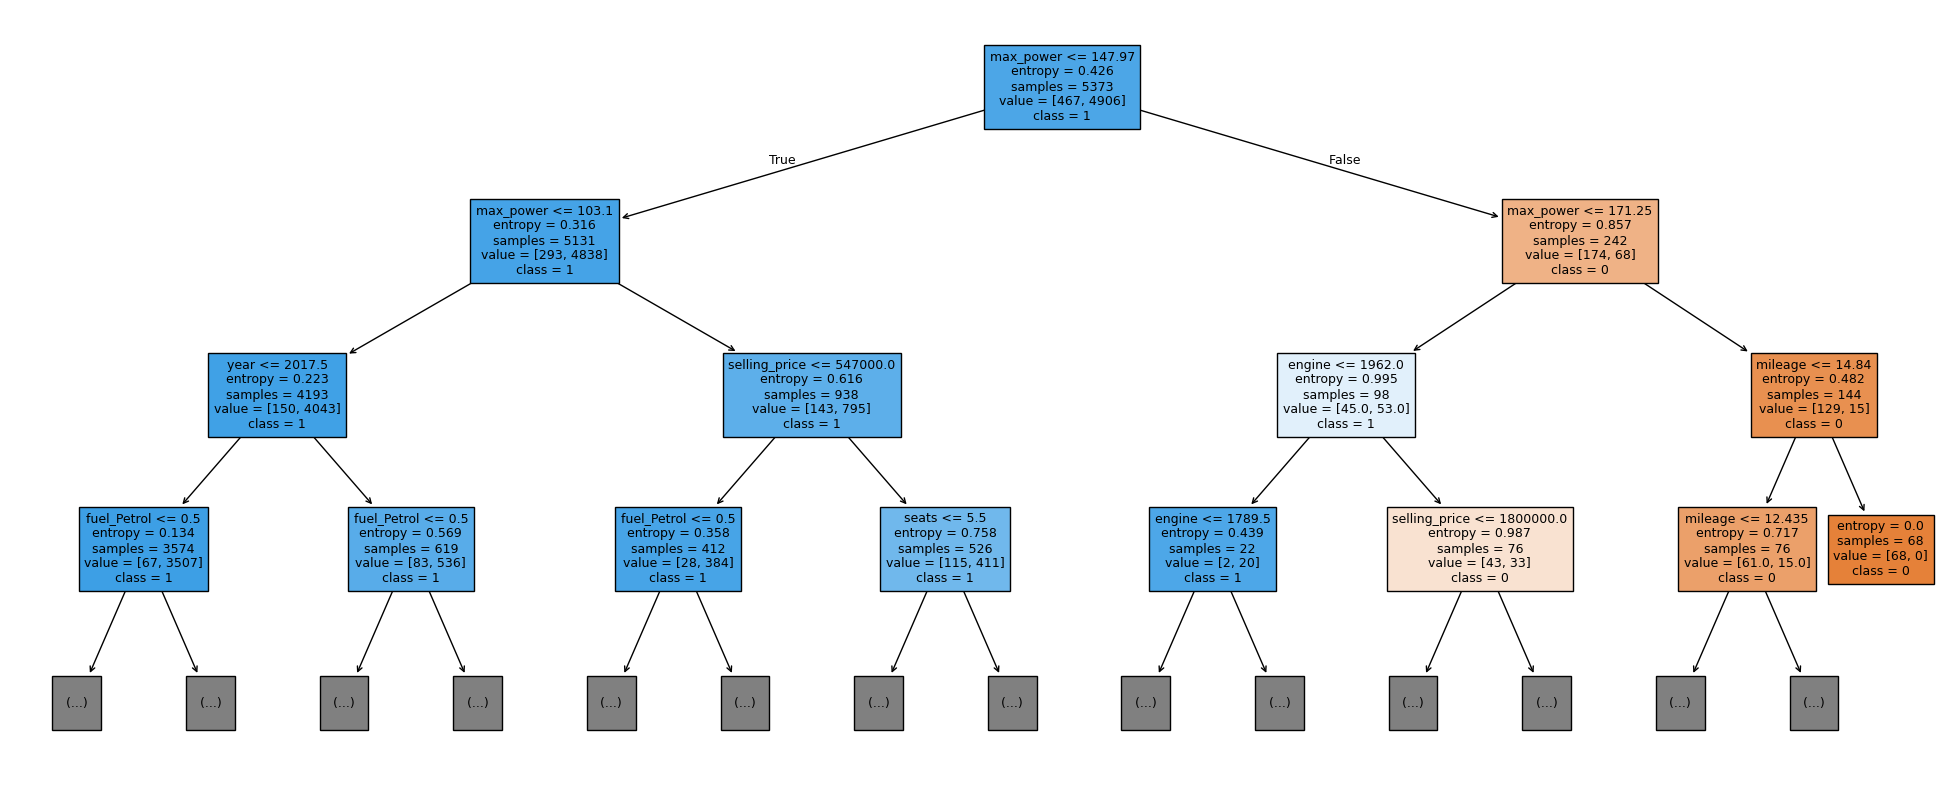

In [33]:
fig = plt.figure(figsize=(25,10))
_ = tree.plot_tree(arbol, max_depth=3, feature_names=X.columns, class_names=["0", "1"], filled=True, fontsize=9)

In [34]:
# También podemos guardar esta figura como una imagen.

fig.savefig("decistion_tree.png")